## An introduction to explainable AI with Shapley values

Shapley values are a widely used approach from cooperative game theory that come with desirable properties. This tutorial is designed to help build a solid understanding of how to compute and interpret Shapley-based explanations of machine learning models. 

We will take a practical hands-on approach, using the shap Python package to explain progressively more complex models. 

Reference: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

#### Outline
- Explaining a linear regression model
- Explaining a boosted tree model
- Shap values for global explainability
- Dealing with one-hot encoded features

## Explaining a linear regression model

Before using Shapley values to explain complicated models, it is helpful to understand how they work for simple models. One of the simplest model types is standard linear regression, and so below we train a linear regression model on the California housing dataset, a simplified, cleaned and preprocessed version of the dataset we used in Chapter 2. This dataset consists of 20640 blocks of houses across California in 1990, where our goal is to predict the natural log of the median home price from 8 different features:

- MedInc - median income in block group
- HouseAge - median house age in block group
- AveRooms - average number of rooms per household
- AveBedrms - average number of bedrooms per household
- Population - block group population
- AveOccup - average number of household members
- Latitude - block group latitude
- Longitude - block group longitude

In [1]:
import sklearn

import shap

# a classic housing price dataset
X, y = shap.datasets.california(n_points=1000)

X100 = shap.utils.sample(X, 100)  # 100 instances for use as the background distribution

# a simple linear model
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)


c:\REPOS\course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Examining the model coefficients
The most common way of understanding a linear model is to examine the coefficients learned for each feature. These coefficients tell us how much the model output changes when we change each of the input features:

In [2]:
print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))

Model coefficients:

MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272


While coefficients are great for telling us what will happen when we change the value of an input feature, by themselves they are not a great way to measure the overall importance of a feature. This is because the value of each coefficient depends on the scale of the input features. If for example we were to measure the age of a home in minutes instead of years, then the coefficients for the HouseAge feature would become 0.0115 / (365∗24∗60) = 2.18e-8. Clearly the number of years since a house was built is not more important than the number of minutes, yet its coefficient value is much larger. This means that the magnitude of a coefficient is not necessarily a good measure of a feature’s importance in a linear model.

#### A more complete picture using partial dependence plots
To understand a feature’s importance in a model, it is necessary to understand both how changing that feature impacts the model’s output, and also the distribution of that feature’s values. To visualize this for a linear model we can build a classical partial dependence plot and show the distribution of feature values as a histogram on the x-axis:

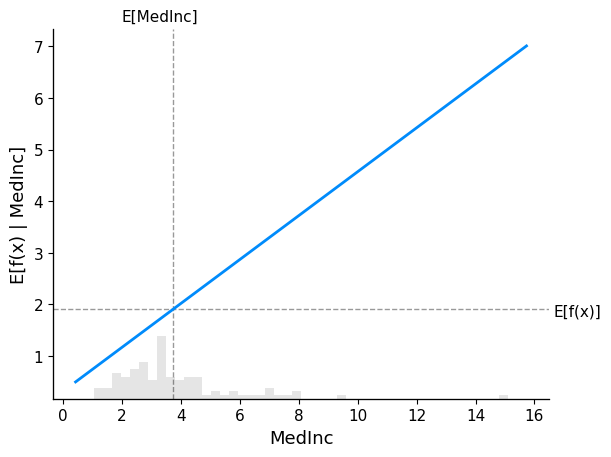

In [3]:
shap.partial_dependence_plot(
    "MedInc", # feature to plot
    model.predict, # the model's prediction function
    X100, # background dataset used to integrate out features
    ice=False, # only show the average effect
    model_expected_value=True, # show the expected value of the model
    feature_expected_value=True, # show the expected value of the feature
)

- The gray horizontal line in the plot above represents the expected (average) value of the model when applied to the California housing dataset. 
- The vertical gray line represents the average value of the median income feature.  
- Note that the blue partial dependence plot line (which is the average value of the model output when we fix the median income feature to a given value) always passes through the intersection of the two gray expected value lines 
- It is a straight line here because we are using a linear model. 
- We can consider this intersection point as the “center” of the partial dependence plot with respect to the data distribution. 
- The impact of this centering will become clear when we turn to Shapley values next.

#### Reading SHAP values from partial dependence plots

- The core idea behind Shapley value based explanations of machine learning models is to use fair allocation results from cooperative game theory to allocate credit for a model's output among its input features.
- In order to connect game theory with machine learning models, it is necessary to both match a model's input features with players in a game, and also match the model function with the rules of the game.
- Since in game theory a player can join or not join a game, we need a way for a feature to "join" or "not join" a model. The most common way to define what it means for a feature to "join" a model is to say that a feature has "joined a model" when we know the value of that feature, and it has not joined a model when we don't know the value of that feature.
- To evaluate an existing model when only a subset of features are part of the model, we integrate out the other features using a conditional expected value formulation.
- This formulation can take two forms:

$$
E[f(X) \mid X_S = x_S]
$$

or

$$
E[f(X) \mid \operatorname{do}(X_S = x_S)]
$$

- In the first form we know the values of the features in $S$ because we observe them. 
- In the second form we know the values of the features in $S$ because we set them. 
- In general, the second form is usually preferable, both because it tells us how the model would behave if we were to intervene and change its inputs, and also because it is much easier to compute. 
- In this tutorial we will focus entirely on the second formulation. 
- We will also use the more specific term "SHAP values" to refer to Shapley values applied to a conditional expectation function of a machine learning model.
  

- SHAP values can be very complicated to compute, but linear models are so simple that we can read the SHAP values right off a partial dependence plot. 
- When we are explaining a prediction $f(x)$, the SHAP value for a specific feature $i$ is just the difference between the expected model output and the partial dependence plot at the feature's value $x_i$:


ExactExplainer explainer: 1001it [00:14, 51.95it/s]                          


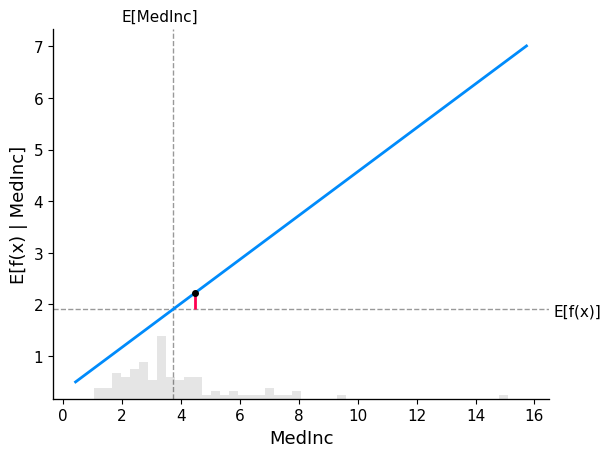

In [4]:
# compute the SHAP values for the linear model
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)

# make a standard partial dependence plot
sample_ind = 85 # index of the instance to show the SHAP values for
shap.partial_dependence_plot(
    "MedInc",
    model.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :], # only show the SHAP values for the single instance
)

The red line is the local SHAP contribution of that feature for the selected instance.

In that plot, you pick one point $x_i$ (for example that sample's MedInc sample_ind = 5), and the red segment shows:

$$
\phi_i \approx \text{PDP}(x_i) - \mathbb{E}[f(X)]
$$

How to read it:

- Direction: above the baseline means this feature pushes the prediction up; below means it pushes it down.
- Length: longer line means a larger absolute effect for that specific sample.
- Local, not global: it explains one prediction at one $x_i$, not overall feature importance.

So the red line is literally "how far this sample is from average on that feature, scaled by the coefficient."

#### The additive nature of Shapley values
One of the fundamental properties of Shapley values is that they always sum up to the difference between the game outcome when all players are present and the game outcome when no players are present. For machine learning models this means that SHAP values of all the input features will always sum up to the difference between baseline (expected) model output and the current model output for the prediction being explained. The easiest way to see this is through a waterfall plot that starts at our background prior expectation for a home price $\mathbb{E}[f(X)$, and then adds features one at a time until we reach the current model output $f(X)$ (read this diagram bottom-up):

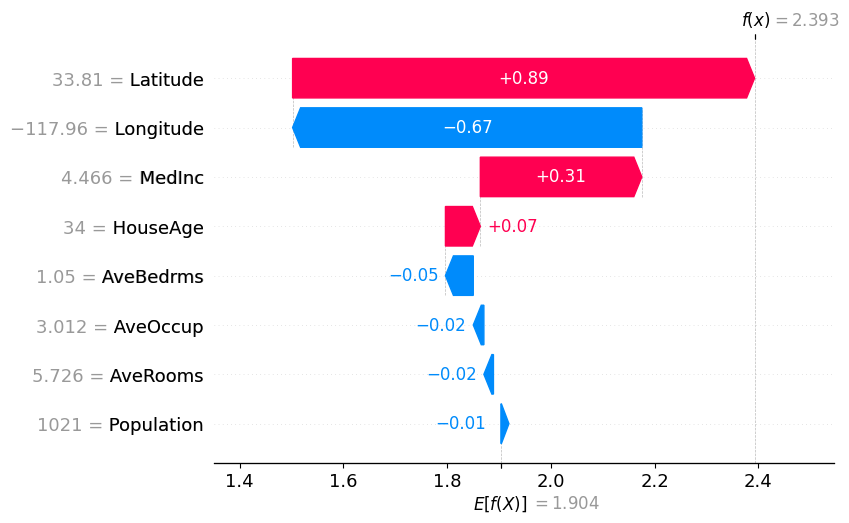

In [5]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

This plot shows the contribution (positive or negative) of each individual feature to the house price of 2.3 for this sample. We learn that latitude and longitude have by far the largest contribution. 

We observe that for very small shap values, the arrow can point in the "wrong" direction. We can ignore that. 

Exercise: observe what happens to the waterfall diagram if you take another sample, illustrating this is a local explainability technique. 

## Explaining a boosted tree model

We make an XGBoost model for the prepared solar data we used in notebook 230. 

In [6]:
import pandas as pd
solar = pd.read_csv('datasets/solar_prepared.csv')
print(solar.head())
print(solar.info())


   dayinyear  sunrise_delta  sunset_delta  temp  pressure  cloudiness  \
0         70             10             1  6.30  1011.625         7.0   
1         70             11             0  5.95  1011.500         7.0   
2         70             12            -1  5.25  1011.850         7.0   
3         70             13            -2  4.85  1011.650         7.0   
4         70             14            -3  4.90  1011.700         7.0   

   humidity_relative  production  
0          57.800000        0.48  
1          60.366667        0.15  
2          64.500000        0.01  
3          68.633333        0.00  
4          68.400000        0.00  
<class 'pandas.DataFrame'>
RangeIndex: 9336 entries, 0 to 9335
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dayinyear          9336 non-null   int64  
 1   sunrise_delta      9336 non-null   int64  
 2   sunset_delta       9336 non-null   int64  
 3   temp       

In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = solar.drop(columns=['production'])
y = solar['production']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [16]:
# check the performance of the model on the test set
from sklearn.metrics import mean_absolute_error
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.4f} kWh")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:day_night_twilight: str

Looking for a good sample

In [15]:
y_train[y_train > 0.5]

1732    1.2170
2088    1.7873
3443    1.1605
7372    0.9907
9003    1.2497
         ...  
1899    1.9243
2734    0.9629
7849    0.5095
769     0.7392
1685    1.1305
Name: production, Length: 1339, dtype: float64

In [8]:
sample = 1732
print(X_train.loc[sample])
print()
print(y_train.loc[sample])
print()
print("xgb_model.predict:", xgb_model.predict(X_train.loc[[sample]]))

dayinyear             145.000000
sunrise_delta          12.000000
sunset_delta            4.000000
temp                   16.000000
pressure             1028.525000
cloudiness              4.000000
humidity_relative      66.766667
Name: 1732, dtype: float64

1.2169999999999843

xgb_model.predict: [1.2855055]


The chosen sample is a rather sunny (cloudiness 4 out of 8) day in May  (dayinyear = 145) at late afternoon (sunset_delta = 4 hrs) with a production of 1.7 kWh during that hour.

 98%|===================| 7283/7468 [00:36<00:00]        

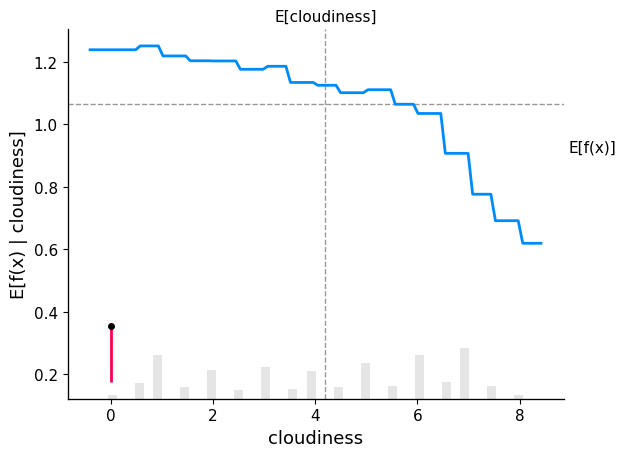

In [9]:
# Explain the model using SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_train)

# use instances for use as the background distribution  with > 0.5 kWh production
X_big_production = X_train[y_train > 0.5]

# make a standard partial dependence plot with a single SHAP value overlaid
# for the cloudiness
fig, ax = shap.partial_dependence_plot(
    "cloudiness",
    xgb_model.predict,
    X_big_production,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values[sample : sample + 1, :],
)

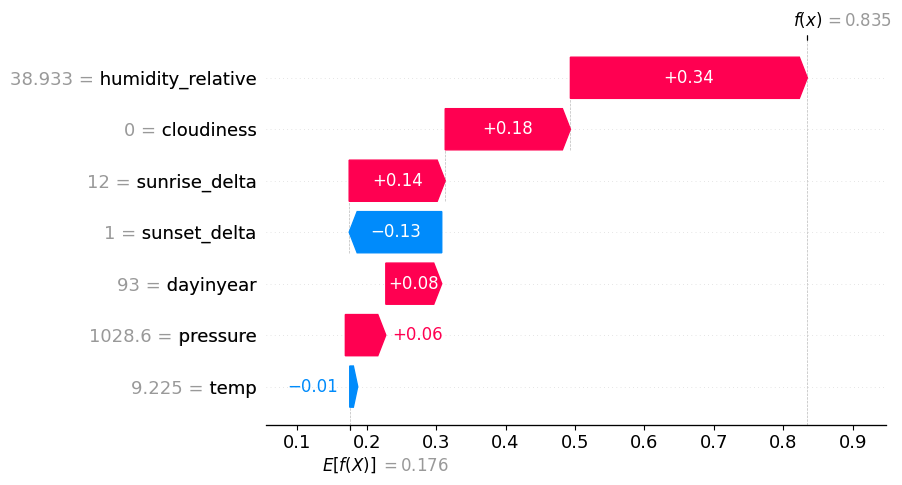

In [10]:
shap.plots.waterfall(shap_values[sample], max_display=14)

It turns out that for this single instance the humidity is the most important factor, followed by the cloudiness and the deltas to sunrise and sunset. 

## Shap values for global explainability

- `shap_values` contains one row per training sample.
- `shap.plots.bar(shap_values)`calculates the mean absolute SHAP value over all rows and sorts from largest to smallest.
- How to interpret it:
1. Bigger bar means that feature changes predictions more on average.
2. It does not show direction (up or down), only magnitude because of the absolute value.
3. It summarizes over all rows in `shap_values` (global view), not one single sample.

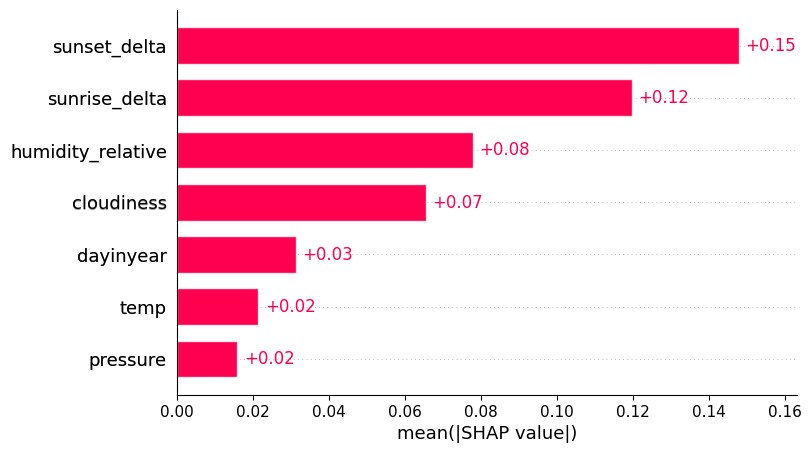

In [11]:
shap.plots.bar(shap_values)

In [12]:
# Let's compare to the feature importance from the XGBoost model itself
xgb_importance = xgb_model.get_booster().get_score(importance_type="gain")
xgb_importance = pd.DataFrame(
    {"feature": list(xgb_importance.keys()), "importance": list(xgb_importance.values())}
).sort_values("importance", ascending=False)


In [13]:
xgb_importance.head(10)

,feature,importance
2,sunset_delta,2.667703
6,humidity_relative,2.326614
1,sunrise_delta,0.702995
5,cloudiness,0.604991
0,dayinyear,0.114536
4,pressure,0.105395
3,temp,0.084851


             feature  importance
2       sunset_delta    0.403764
6  humidity_relative    0.352139
1      sunrise_delta    0.106400
5         cloudiness    0.091567
0          dayinyear    0.017335
4           pressure    0.015952
3               temp    0.012843


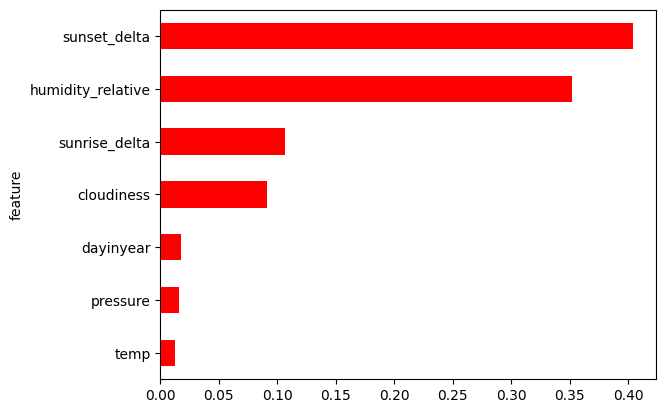

In [14]:
# Let's compare to the feature importance from the XGBoost model itself
xgb_importance_df = pd.DataFrame(
    {"feature": X_train.columns, "importance": xgb_model.feature_importances_}
).sort_values("importance", ascending=False)
print(xgb_importance_df.head(10))
# display the feature importance from XGBoost as a horizontal bar chart with the most important feature at the top
ax = xgb_importance_df.plot.barh(x="feature", y="importance", legend=False, color="red")
ax.invert_yaxis()

Although the two rankings are similar, they differ in some features. This demonstrates the difference between in-model explanation (feature importances) and post-model explanation (shap values). 

## Dealing with one-hot encoded features

Since shap values are additive all we have to do is just sum the shap values for each one-hot-encoded feature. 

In [17]:
from sklearn.metrics import mean_absolute_error
# let's add a new categorical feature to the solar dataset: day_night_twilight as follows:
# - day: sunrise_delta > 1 and sunset_delta > 1
# - night: sunrise_delta < -1 or sunset_delta < -1
# - twilight: otherwise
def day_night_twilight(row):
    if row["sunrise_delta"] > 1 and row["sunset_delta"] > 1:
        return "day"
    elif row["sunrise_delta"] < -1 or row["sunset_delta"] < -1:
        return "night"
    else:
        return "twilight"

X_train["day_night_twilight"] = X_train.apply(day_night_twilight, axis=1)
X_test["day_night_twilight"] = X_test.apply(day_night_twilight, axis=1)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# we need to one-hot encode the new categorical feature
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), ["day_night_twilight"]),
    ],
    remainder="passthrough",
)
# from sklearn.pipeline import Pipeline
# xgb_pipeline = Pipeline(    
#     steps=[
#         ("preprocessor", preprocessor),
#         ("model", XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42)),
#     ]
# )
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
xgb_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_encoded, y_train)
# evaluate the performance of the new pipeline on the test set
y_pred = xgb_model.predict(X_test_encoded)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE with day_night_twilight: {mae:.4f} kWh")

Test MAE with day_night_twilight: 0.0632 kWh


In [18]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=preprocessor.get_feature_names_out())
X_train_encoded.head()

,cat__day_night_twilight_day,cat__day_night_twilight_night,cat__day_night_twilight_twilight,remainder__dayinyear,remainder__sunrise_delta,remainder__sunset_delta,remainder__temp,remainder__pressure,remainder__cloudiness,remainder__humidity_relative
0,1.0,0.0,0.0,227.0,6.0,9.0,20.000,1016.825,4.5,76.833333
1,0.0,0.0,1.0,224.0,15.0,0.0,19.150,1017.150,7.0,66.633333
2,0.0,1.0,0.0,6.0,16.0,-8.0,4.250,1018.125,6.5,86.066667
3,0.0,1.0,0.0,357.0,14.0,-6.0,10.600,1012.550,4.5,81.933333
4,1.0,0.0,0.0,243.0,4.0,10.0,15.175,1011.575,4.0,90.000000


In [24]:
# remove cat__ and remainder__ from the column names
X_train_encoded.columns = X_train_encoded.columns.str.replace("cat__", "").str.replace("remainder__", "")
X_train_encoded.head()

,day_night_twilight_day,day_night_twilight_night,day_night_twilight_twilight,dayinyear,sunrise_delta,sunset_delta,temp,pressure,cloudiness,humidity_relative
0,1.0,0.0,0.0,227.0,6.0,9.0,20.000,1016.825,4.5,76.833333
1,0.0,0.0,1.0,224.0,15.0,0.0,19.150,1017.150,7.0,66.633333
2,0.0,1.0,0.0,6.0,16.0,-8.0,4.250,1018.125,6.5,86.066667
3,0.0,1.0,0.0,357.0,14.0,-6.0,10.600,1012.550,4.5,81.933333
4,1.0,0.0,0.0,243.0,4.0,10.0,15.175,1011.575,4.0,90.000000


In [19]:
# Explain the model using SHAP
explainer = shap.Explainer(xgb_model, X_train_encoded)
shap_values = explainer(X_train_encoded)

 98%|===================| 7299/7468 [00:38<00:00]        

In [20]:
# combine the SHAP values for the one-hot encoded features into a single SHAP value 
# for the original categorical feature

# The first 3 columns are the OHE columns: day_night_twilight_day, _night, _twilight
# Sum their SHAP values to get the net effect of the original categorical feature

import numpy as np

combined_values = np.hstack([
    shap_values.values[:, :3].sum(axis=1, keepdims=True),
    shap_values.values[:, 3:]
])

# For data, use the original category string from X_train (reset index to align)
combined_data = np.hstack([
    X_train["day_night_twilight"].values.reshape(-1, 1),
    shap_values.data[:, 3:]
])

combined_feature_names = ["day_night_twilight"] + list(shap_values.feature_names[3:])

shap_values_combined = shap.Explanation(
    values=combined_values,
    base_values=shap_values.base_values, # the base value is the same for all features, so we can just take it from the original SHAP values
    data=combined_data,
    feature_names=combined_feature_names
)

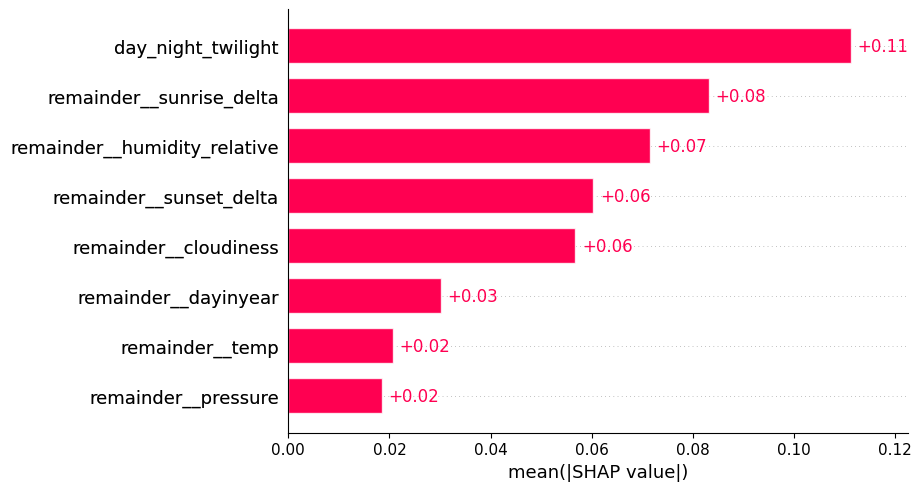

In [21]:
# global explanation with the combined SHAP values
shap.plots.bar(shap_values_combined)

                        feature  importance
0            day_night_twilight    0.544302
7  remainder__humidity_relative    0.179777
3       remainder__sunset_delta    0.111258
6         remainder__cloudiness    0.076295
2      remainder__sunrise_delta    0.055298
1          remainder__dayinyear    0.012724
5           remainder__pressure    0.012405
4               remainder__temp    0.007941


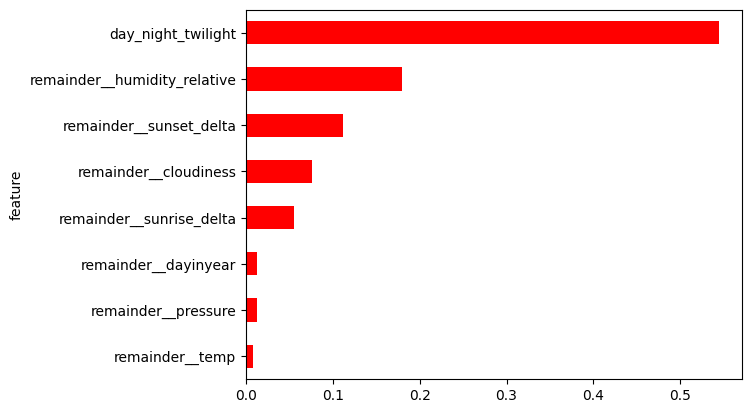

In [23]:
# Combine the importances of the 3 OHE columns into one for day_night_twilight
ohe_cols = ["cat__day_night_twilight_day", "cat__day_night_twilight_night", "cat__day_night_twilight_twilight"]
other_cols = [c for c in X_train_encoded.columns if c not in ohe_cols]

combined_importance = {
    "day_night_twilight": xgb_model.feature_importances_[:3].sum()
}
combined_importance.update(
    dict(zip(other_cols, xgb_model.feature_importances_[3:]))
)

xgb_importance_df = (
    pd.DataFrame(list(combined_importance.items()), columns=["feature", "importance"])
    .sort_values("importance", ascending=True)   # ascending=True so largest is at the top in barh
)

print(xgb_importance_df.sort_values("importance", ascending=False).head(10))

ax = xgb_importance_df.plot.barh(x="feature", y="importance", legend=False, color="red")
# ax.invert_yaxis()


We can also use local explainability for the same sample as above using the combined shap values: 

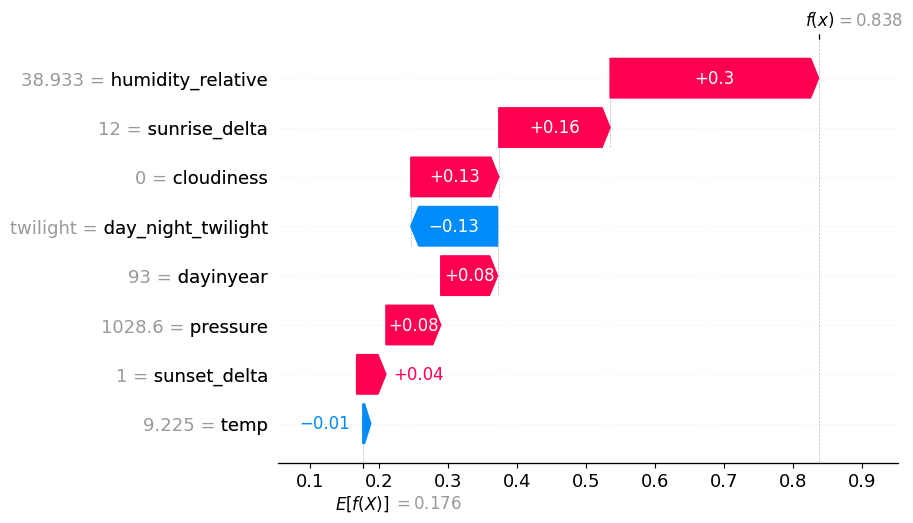

In [41]:
shap.plots.waterfall(shap_values_combined[sample], max_display=14)